# Notebook 03 — Adaptive Canny Edge Detection

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 3:** Grayscale + CLAHE + Gaussian blur → Otsu thresholding → Canny edge detection

**Input:**
- Rectified images from `outputs/02_rectified/`
- Calibration data from `outputs/02_rectified/calibration.json`

**Output:**
- Binary edge maps saved to `outputs/03_canny/`

**Key idea:** Instead of manually selecting Canny thresholds, Otsu's method computes
an optimal threshold from the grayscale histogram automatically:
```
t_low  = 0.5 · t_otsu
t_high = t_otsu
```
This makes the detector robust to illumination changes across images (Liu et al., 2024).

## 1. Imports and configuration

In [21]:
%pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [23]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")
CALIB_PATH    = RECTIFIED_DIR / "calibration.json"
OUTPUT_DIR    = Path("outputs/03_canny")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Preprocessing parameters (same as Notebook 01) ────────────────────────

CLAHE_CLIP_LIMIT = 1.0
CLAHE_TILE_GRID  = (8, 8)
GAUSSIAN_KERNEL  = (7, 7)   # intermedio entre 5 y 11
GAUSSIAN_SIGMA   = 0

# ── Canny parameters ───────────────────────────────────────────────────────
# Thresholds are derived automatically from Otsu:
#   t_low  = OTSU_LOW_RATIO  * t_otsu
#   t_high = t_otsu
OTSU_LOW_RATIO = 0.5

# Load calibration data from notebook 02
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)

print(f"Rectified dir  : {RECTIFIED_DIR.resolve()}")
print(f"Output dir     : {OUTPUT_DIR.resolve()}")
print(f"Calibrated imgs: {len(calibration_data)}")

Rectified dir  : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Output dir     : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Calibrated imgs: 22


## 2. Preprocessing

We apply the same preprocessing as Notebook 01 but now on the **rectified** images
from Notebook 02, so that the edge map is already in the corrected coordinate system.

In [24]:
def preprocess(img_bgr: np.ndarray) -> np.ndarray:
    """
    Grayscale → CLAHE → Gaussian blur.
    Returns the blurred grayscale image ready for Canny.
    """
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe   = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)
    equalized = clahe.apply(gray)
    blurred = cv2.GaussianBlur(equalized, GAUSSIAN_KERNEL, GAUSSIAN_SIGMA)
    #blurred = cv2.GaussianBlur(gray, GAUSSIAN_KERNEL, GAUSSIAN_SIGMA)
    return blurred

## 3. Adaptive Canny with Otsu thresholds

Otsu's method finds the threshold that maximises inter-class variance in the
grayscale histogram, producing a bimodal split between dark (rubber) and
light (table background) regions. We use this as the high threshold for Canny
and half of it as the low threshold, following Liu et al. (2024).

In [25]:
def adaptive_canny(blurred: np.ndarray) -> tuple[np.ndarray, float, float]:
    """
    Apply Canny edge detection with thresholds derived from Otsu's method.

    Parameters
    ----------
    blurred : np.ndarray — preprocessed grayscale image

    Returns
    -------
    edges   : np.ndarray — binary edge map
    t_low   : float — low threshold used
    t_high  : float — high threshold used (= Otsu threshold)
    """
    # Compute Otsu threshold on the blurred image
    t_otsu, _ = cv2.threshold(blurred, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    t_high = float(t_otsu)
    t_low  = OTSU_LOW_RATIO * t_high

    edges = cv2.Canny(blurred,
                      threshold1=t_low,
                      threshold2=t_high)
    return edges, t_low, t_high

## 4. Full pipeline per image

In [26]:
def process_image(image_name: str) -> dict:
    """
    Load rectified image, preprocess, apply adaptive Canny, save edge map.

    Returns a dict with t_low, t_high, and edge_density for diagnostics.
    """
    img_path = RECTIFIED_DIR / image_name
    img      = cv2.imread(str(img_path))
    if img is None:
        print(f"  [SKIP] Could not load {image_name}")
        return None

    blurred            = preprocess(img)
    edges, t_low, t_high = adaptive_canny(blurred)

    out_path = OUTPUT_DIR / image_name
    cv2.imwrite(str(out_path), edges)

    return {
        'image_name'   : image_name,
        't_low'        : t_low,
        't_high'       : t_high,
        'edge_density' : float(np.mean(edges > 0))
    }

In [27]:
canny_results = {}

for image_name in calibration_data:
    result = process_image(image_name)
    if result is not None:
        canny_results[image_name] = result
        print(f"  [OK] {image_name:30s}  "
              f"t_low={result['t_low']:6.1f}  "
              f"t_high={result['t_high']:6.1f}  "
              f"edge_density={result['edge_density']:.4f}")

print(f"\nProcessed {len(canny_results)} / {len(calibration_data)} images")

  [OK] Multimedia_31.jpg               t_low=  68.5  t_high= 137.0  edge_density=0.0136
  [OK] Multimedia_32.jpg               t_low=  66.0  t_high= 132.0  edge_density=0.0135
  [OK] Multimedia_33.jpg               t_low=  66.0  t_high= 132.0  edge_density=0.0095
  [OK] Multimedia_34.jpg               t_low=  68.5  t_high= 137.0  edge_density=0.0138
  [OK] Multimedia_35.jpg               t_low=  39.0  t_high=  78.0  edge_density=0.0022
  [OK] Multimedia_36.jpg               t_low=  45.0  t_high=  90.0  edge_density=0.0040
  [OK] Multimedia_37.jpg               t_low=  53.0  t_high= 106.0  edge_density=0.0083
  [OK] Multimedia_38.jpg               t_low=  49.5  t_high=  99.0  edge_density=0.0047
  [OK] Multimedia_39.jpg               t_low=  67.0  t_high= 134.0  edge_density=0.0125
  [OK] Multimedia_40.jpg               t_low=  65.5  t_high= 131.0  edge_density=0.0101
  [OK] Multimedia_41.jpg               t_low=  83.0  t_high= 166.0  edge_density=0.0243
  [OK] Multimedia_42.jpg        

## 5. Visual inspection

Show the preprocessing stages and the final edge map for one example image.

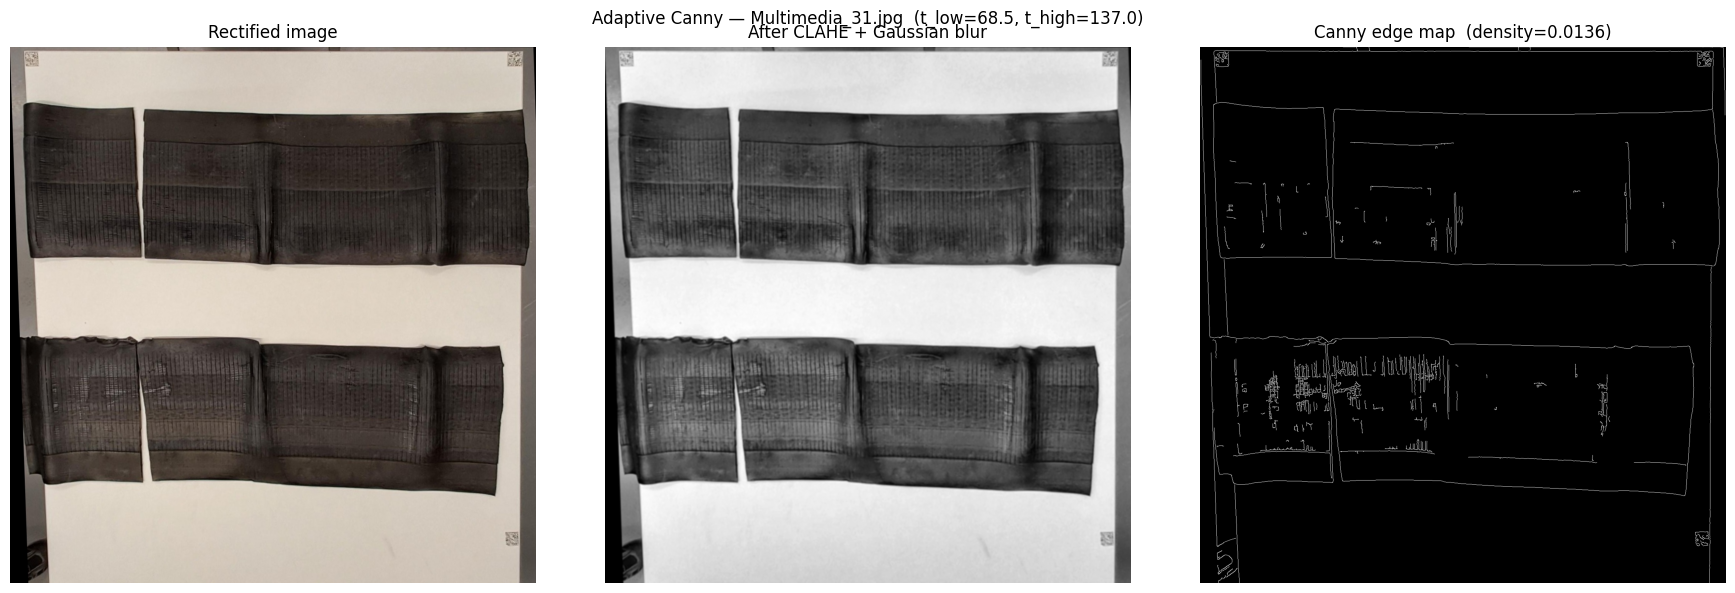

In [28]:
def visualize_canny(image_name: str):
    img      = cv2.imread(str(RECTIFIED_DIR / image_name))
    blurred  = preprocess(img)
    edges, t_low, t_high = adaptive_canny(blurred)
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Adaptive Canny — {image_name}  "
                 f"(t_low={t_low:.1f}, t_high={t_high:.1f})", fontsize=12)

    axes[0].imshow(img_rgb)
    axes[0].set_title("Rectified image")
    axes[0].axis("off")

    axes[1].imshow(blurred, cmap="gray")
    axes[1].set_title("After CLAHE + Gaussian blur")
    axes[1].axis("off")

    axes[2].imshow(edges, cmap="gray")
    axes[2].set_title(f"Canny edge map  (density={np.mean(edges>0):.4f})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"check_{image_name}", dpi=120)
    plt.show()


# Visualize first image
visualize_canny(next(iter(canny_results)))

In [29]:
# Visualize a different image — change name here
# visualize_canny("Multimedia_42.jpg")

## 6. Otsu threshold distribution

Check that the adaptive thresholds are consistent across images.
Large variations indicate images with very different lighting conditions.

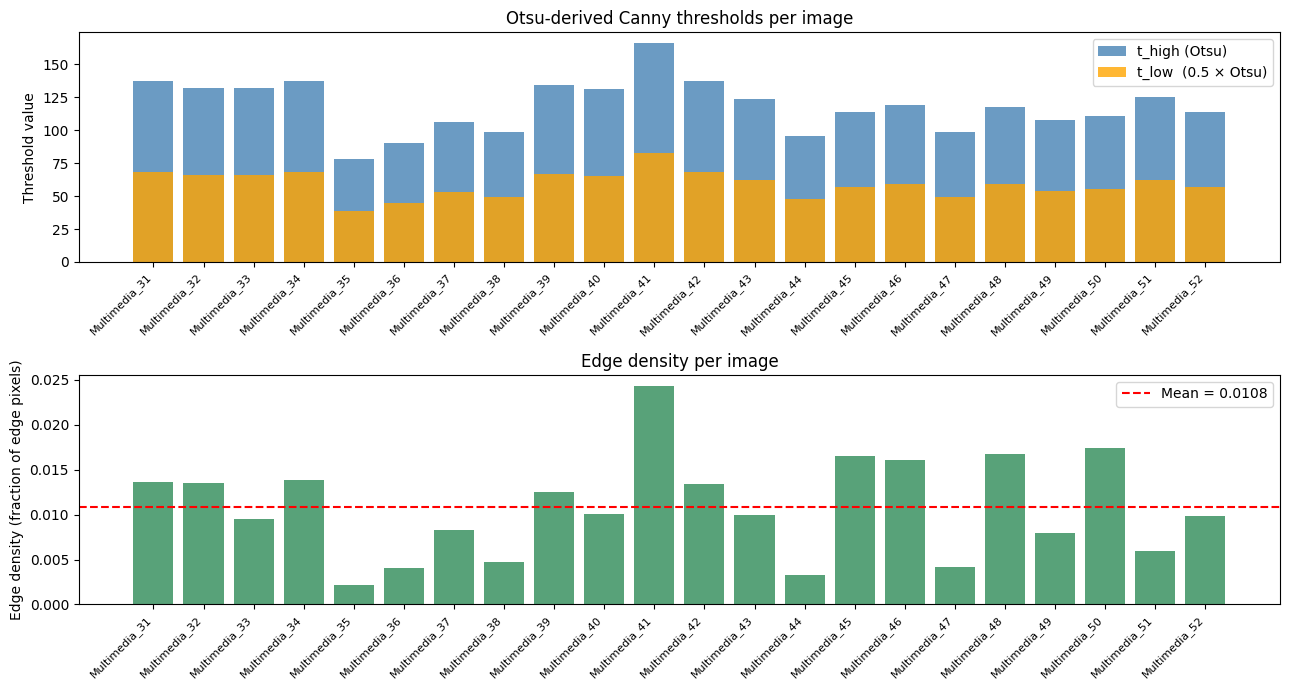

Mean t_high     : 118.5
Std  t_high     : 19.3
Mean edge dens. : 0.0108
Std  edge dens. : 0.0055


In [30]:
names   = list(canny_results.keys())
t_highs = [canny_results[n]['t_high'] for n in names]
t_lows  = [canny_results[n]['t_low']  for n in names]
densities = [canny_results[n]['edge_density'] for n in names]

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Thresholds
x = range(len(names))
axes[0].bar(x, t_highs, color='steelblue', alpha=0.8, label='t_high (Otsu)')
axes[0].bar(x, t_lows,  color='orange',    alpha=0.8, label='t_low  (0.5 × Otsu)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace('.jpg','') for n in names],
                         rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Threshold value')
axes[0].set_title('Otsu-derived Canny thresholds per image')
axes[0].legend()

# Edge density
axes[1].bar(x, densities, color='seagreen', alpha=0.8)
axes[1].axhline(np.mean(densities), color='red', linestyle='--',
                label=f'Mean = {np.mean(densities):.4f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace('.jpg','') for n in names],
                         rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Edge density (fraction of edge pixels)')
axes[1].set_title('Edge density per image')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'canny_diagnostics.png', dpi=150)
plt.show()

print(f"Mean t_high     : {np.mean(t_highs):.1f}")
print(f"Std  t_high     : {np.std(t_highs):.1f}")
print(f"Mean edge dens. : {np.mean(densities):.4f}")
print(f"Std  edge dens. : {np.std(densities):.4f}")

## 7. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 3a | Grayscale + CLAHE | clipLimit=2.0, tileGrid=(8,8) |
| 3b | Gaussian blur | kernel=(5,5) |
| 3c | Otsu threshold | `cv2.THRESH_OTSU` on blurred image |
| 3d | Canny | t_low = 0.5·t_otsu, t_high = t_otsu |

**Output folder:** `outputs/03_canny/`  
**Next notebook:** `04_hough.ipynb` — ROI extraction, Probabilistic Hough Transform, geometric filtering